# Лабораторная работа E15 — Итоговая работа: управление схватом по собственной ЭМГ в реальном времени

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biomenace/digital-signal-processing/blob/main/notebooks/e15.ipynb)

Ноутбук-спутник к интерактивной работе: **[открыть саму лабораторную](https://biomenace.github.io/digital-signal-processing/labs/e15.html)**.

**Что разбираем.** Последняя работа серии собирает всё вместе: сигнал идёт
потоком, и на каждом шаге нужно выдать команду клешне. Ни одного взгляда
вперёд — только то, что уже пришло:

```
поток → каузальное окно → RMS → порог с гистерезисом → голосование K окон → клешня
```

Мерить качество здесь нужно двумя числами сразу, и они тянут в разные
стороны:

* **ложные срабатывания** — сколько раз клешня дёрнулась, когда рука была
  расслаблена. Их гасят сглаживанием, гистерезисом и голосованием;
* **задержка отклика** — сколько миллисекунд проходит между настоящим
  сжатием и движением клешни. Всё, что гасит дребезг, эту задержку растит.

Задача лабы — увидеть обмен между ними своими глазами и выбрать рабочую точку.
Запись, как в E13 и E14, синтетическая; заменить её на живой поток с датчика
значит поменять одну ячейку.

In [1]:
# ЯЧЕЙКА 1 · Установка и импорты.
# Запусти один раз в начале работы и больше сюда не возвращайся.
# В Google Colab почти всё уже стоит, поэтому обычно ничего не скачивается.

import importlib.util
import subprocess
import sys


def ensure(packages):
    """Ставит только те пакеты, которых нет. packages: [(модуль, имя-для-pip)]."""
    missing = [pip for mod, pip in packages if not importlib.util.find_spec(mod)]
    if missing:
        print("Ставлю:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing],
                       check=True)
    print("Готово. Python", sys.version.split()[0])


ensure([("numpy", "numpy"), ("scipy", "scipy"), ("matplotlib", "matplotlib")])

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline
matplotlib.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.linewidth": 0.4,
    "axes.titlesize": 12,
    "font.size": 11,
})

Готово. Python 3.10.12


In [2]:
# ЯЧЕЙКА · Свой сигнал: имитация сенсора, которого нет.
# Честно: настоящего ЭМГ-датчика у нас в ноутбуке нет, поэтому «свою» запись
# мы синтезируем. Модель простая и физически осмысленная: ЭМГ — это шум,
# профильтрованный в полосу 20–450 Гц, амплитуда которого следует за усилием
# мышцы. Сюда же добавляются болезни реального тракта: наводка 50 Гц, дрейф
# нуля и постоянное смещение. Когда появится железо, меняется только источник
# сигнала — вся остальная обработка остаётся той же.

from scipy.signal import butter, filtfilt, iirnotch

FS = 1000.0                  # частота дискретизации, Гц
BAND = (20.0, 450.0)         # рабочая полоса ЭМГ


def bandpass(x, fs=FS, lo=BAND[0], hi=BAND[1], order=4):
    """Полосовой фильтр Баттерворта: пропускает только полосу ЭМГ."""
    nyquist = fs / 2.0
    b, a = butter(order, [lo / nyquist, min(hi, nyquist * 0.99) / nyquist],
                  btype="band")
    return filtfilt(b, a, x)


def notch(x, fs=FS, f0=50.0, q=30.0):
    """Режекторный фильтр: вырезает узкую полосу вокруг f0 (сетевая наводка)."""
    b, a = iirnotch(f0 / (fs / 2.0), q)
    return filtfilt(b, a, x)


def rms(x):
    """Эффективная амплитуда сигнала (постоянная составляющая не учитывается)."""
    x = np.asarray(x, float)
    return float(np.sqrt(np.mean((x - np.mean(x)) ** 2)))


def spectrum(x, fs=FS):
    """Амплитудный спектр окна: (частоты, амплитуды)."""
    x = np.asarray(x, float) - np.mean(x)
    return (np.fft.rfftfreq(len(x), d=1.0 / fs),
            np.abs(np.fft.rfft(x * np.hanning(len(x)))))


def power_fraction(x, band, fs=FS):
    """Какая доля энергии сигнала лежит в полосе band = (низ, верх), в герцах."""
    freqs, amplitude = spectrum(x, fs)
    power = amplitude ** 2
    inside = (freqs >= band[0]) & (freqs <= band[1])
    return float(np.sum(power[inside]) / (np.sum(power) + 1e-24))


def band_fraction(x, fs=FS, band=BAND):
    """Доля энергии в рабочей полосе ЭМГ. У чистого сигнала с мышцы — почти вся."""
    return power_fraction(x, band, fs)


def blocks(pattern, seconds):
    """Сценарий усилия из блоков равной длины: [0, 1, 0, 0.6] → покой, сжатие, ..."""
    span = seconds / len(pattern)

    def level(t):
        return pattern[min(len(pattern) - 1, int(t / span))]

    return level


def synth_emg(level_fn, seconds, fs=FS, seed=0, rest=0.05,
              mains=0.0, drift=0.0, offset=0.0, ramp_ms=150.0):
    """«Записать» свой сигнал. Возвращает (x[N], усилие мышцы[N]).

    level_fn(t) задаёт усилие от 0 до 1 в момент t (секунды). Скачки усилия
    сглаживаются за ramp_ms — мышца не включается мгновенно, и вторым значением
    возвращается именно сглаженное усилие: то, что мышца делала на самом деле.
    rest — остаточная активность в покое, mains/drift/offset — грязь тракта в
    тех же единицах.
    """
    rng = np.random.default_rng(seed)
    n = int(seconds * fs)
    t = np.arange(n) / fs

    shaped = bandpass(rng.standard_normal(n), fs)
    shaped /= np.sqrt(np.mean(shaped ** 2)) + 1e-12

    level = np.array([float(level_fn(v)) for v in t])
    width = max(1, int(ramp_ms / 1000.0 * fs))
    kernel = np.hanning(width)
    envelope = np.convolve(level, kernel / kernel.sum(), mode="same")

    x = shaped * (rest + envelope)
    x = x + mains * np.sin(2 * np.pi * 50.0 * t)
    x = x + drift * np.sin(2 * np.pi * 0.7 * t) + offset
    return x, envelope


def add_artifacts(x, mask=None, fs=FS, count=6, amplitude=0.8, ms=60.0, seed=0,
                  gap_ms=500.0):
    """Короткие всплески: подёргивание мышцы, шевеление электрода, толчок кабеля.

    mask — где всплески разрешены (булев массив длины x), gap_ms — минимальный
    промежуток между соседними всплесками, чтобы они не слипались в один.
    Возвращает (сигнал с всплесками, позиции всплесков в отсчётах).
    """
    rng = np.random.default_rng(seed)
    width = int(ms / 1000.0 * fs)
    gap = int(gap_ms / 1000.0 * fs)
    allowed = np.arange(len(x) - width) if mask is None \
        else np.flatnonzero(mask[:len(x) - width])
    if len(allowed) == 0 or count == 0:
        return np.array(x, float), np.array([], int)

    positions = []
    for start in rng.permutation(allowed):
        if all(abs(int(start) - p) >= gap for p in positions):
            positions.append(int(start))
        if len(positions) == count:
            break

    out = np.array(x, float)
    burst = bandpass(rng.standard_normal(width), fs) * np.hanning(width)
    burst = burst / (np.sqrt(np.mean(burst ** 2)) + 1e-12) * amplitude
    for start in positions:
        out[start:start + width] += burst
    return out, np.sort(np.array(positions, int))

## Ячейка 3 · Поток: сжатия, покой и помехи в покое

Сценарий: четыре сжатия разной силы, между ними покой. Отдельно добавляем
то, из-за чего протезы и дёргаются, — короткие всплески **в покое**:
подёргивание мышцы, шевеление электрода, толчок кабеля. Каждый такой всплеск
— кандидат в ложное срабатывание.

In [3]:
SECONDS = 20.0
PATTERN = [0.0, 1.0, 0.0, 0.7, 0.0, 1.0, 0.0, 0.6]     # покой / сжатие, по очереди

signal, effort = synth_emg(blocks(PATTERN, SECONDS), SECONDS, seed=1)
relaxed = effort < 0.5                                  # где мышца расслаблена
signal, bursts = add_artifacts(signal, mask=relaxed, count=6,
                               amplitude=0.8, ms=60.0, seed=4)

print("Поток %.0f с при %.0f Гц. Сжатий: %d, всплесков в покое: %d."
      % (SECONDS, FS, sum(1 for p in PATTERN if p > 0), len(bursts)))
print("Всплески в моменты, с: " + ", ".join("%.1f" % (b / FS) for b in bursts))

Поток 20 с при 1000 Гц. Сжатий: 4, всплесков в покое: 6.
Всплески в моменты, с: 0.8, 1.3, 6.1, 11.4, 15.6, 16.8


## Ячейка 4 · Живой цикл

Кольцевой буфер длиной `WIN_MS` хранит последнее прошлое. Каждые `STEP_MS`
приходит новая порция, буфер сдвигается, считается RMS — и по нему
принимается решение. Ровно этот код и крутился бы в контроллере протеза.

Три ступени защиты от дребезга: нормировка уровня, **гистерезис** (закрыть при
`L > ПОРОГ`, открыть только при `L < ПОРОГ − ГИСТЕРЕЗИС`) и **голосование**
последних `K` решений.

In [4]:
WIN_MS, STEP_MS = 200.0, 25.0        # окно и шаг потока: 40 решений в секунду
THRESHOLD, HYSTERESIS = 0.40, 0.08   # порог закрытия и ширина зазора
NORM = 1.00                          # RMS, который считаем полным усилием
K = 7                                # сколько последних решений голосуют


def live_loop(stream, k=K, threshold=THRESHOLD, hysteresis=HYSTERESIS):
    """Каузальный цикл контроллера. Возвращает (уровень, сырая команда, стабилизированная)."""
    width = int(WIN_MS / 1000.0 * FS)
    step = int(STEP_MS / 1000.0 * FS)
    ring = np.zeros(width)
    votes, closed = [], False
    strength, raw, stable = [], [], []

    for start in range(0, len(stream) - step + 1, step):
        ring = np.concatenate([ring[step:], stream[start:start + step]])
        value = min(1.0, rms(ring) / NORM)
        if not closed and value > threshold:
            closed = True
        elif closed and value < threshold - hysteresis:
            closed = False
        votes = (votes + [closed])[-k:]

        strength.append(value)
        raw.append(closed)
        stable.append(sum(votes) * 2 > len(votes))

    return np.array(strength), np.array(raw), np.array(stable)


step_n = int(STEP_MS / 1000.0 * FS)
level, raw_command, command = live_loop(signal)
truth = effort[np.arange(len(level)) * step_n + step_n - 1]    # что было на самом деле

print("Шагов потока: %d, решение каждые %.0f мс." % (len(level), STEP_MS))

Шагов потока: 800, решение каждые 25 мс.


## Ячейка 5 · Два числа, ради которых всё затевалось

Ложное срабатывание — переключение команды в момент, когда мышца расслаблена.
Задержку считаем не по формуле, а честно: находим каждое настоящее начало
сжатия и смотрим, через сколько миллисекунд клешня закрылась.

In [5]:
def false_triggers(sequence, true_effort):
    """Сколько раз клешня закрылась, когда мышца была расслаблена.

    Считаем только закрытия: открытие в конце сжатия — нормальная работа, а не
    ложное срабатывание.
    """
    closings = np.flatnonzero(sequence[1:] & ~sequence[:-1]) + 1
    return int(np.sum(true_effort[closings] < 0.5))


def response_delay(sequence, true_effort, step_ms=STEP_MS):
    """Средняя задержка между настоящим началом сжатия и закрытием клешни, мс."""
    onsets = np.flatnonzero((true_effort[1:] >= 0.5) & (true_effort[:-1] < 0.5)) + 1
    delays = []
    for onset in onsets:
        after = np.flatnonzero(sequence[onset:])
        if len(after):
            delays.append(after[0] * step_ms)
    return float(np.mean(delays)) if delays else float("nan")


print("Всплесков в покое: %d." % len(bursts))
print("Ложных срабатываний:")
print("   сырое решение:      %d" % false_triggers(raw_command, truth))
print("   после голосования:  %d" % false_triggers(command, truth))
print("\nЗадержка отклика:")
print("   измеренная (сырое решение):     %3.0f мс" % response_delay(raw_command, truth))
print("   измеренная (после голосования): %3.0f мс" % response_delay(command, truth))
print("   оценка сверху WIN/2 + K·шаг =   %3.0f мс" % (WIN_MS / 2 + K * STEP_MS))

Всплесков в покое: 6.
Ложных срабатываний:
   сырое решение:      6
   после голосования:  6

Задержка отклика:
   измеренная (сырое решение):      38 мс
   измеренная (после голосования): 112 мс
   оценка сверху WIN/2 + K·шаг =   275 мс


Измеренная задержка заметно меньше формулы — и это нормально. Формула
`WIN/2 + K·шаг` даёт оценку сверху: она считает, что окно должно заполниться
сокращением целиком. На деле RMS переходит порог раньше, ещё на нарастании
усилия. Формулой пользуются как быстрой прикидкой, а для отчёта задержку
измеряют.

## Ячейка 6 · Три дорожки: сила, сырое решение, клешня

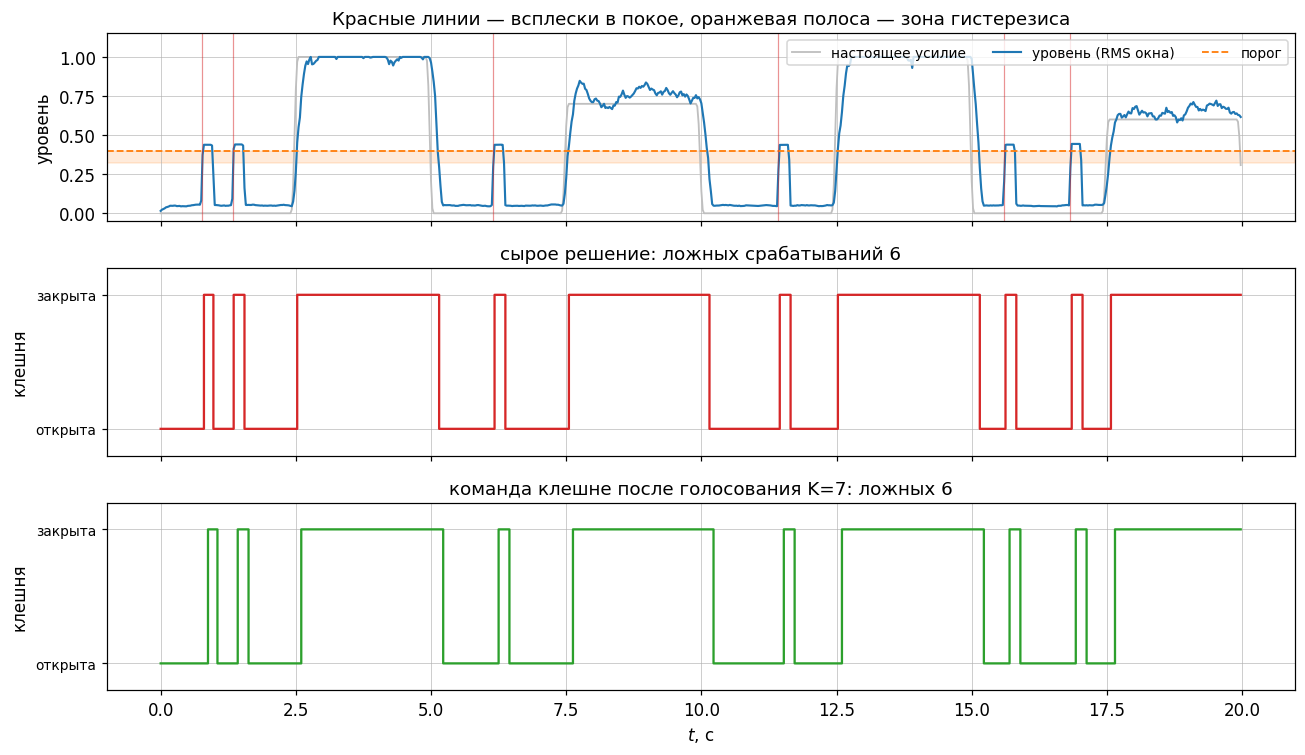

In [6]:
time = np.arange(len(level)) * STEP_MS / 1000.0

fig, (top, middle, bottom) = plt.subplots(3, 1, sharex=True, figsize=(12, 7.0))

top.plot(time, truth, color="0.75", lw=1.2, label="настоящее усилие")
top.plot(time, level, color="tab:blue", lw=1.4, label="уровень (RMS окна)")
top.axhline(THRESHOLD, color="tab:orange", ls="--", lw=1.2, label="порог")
top.axhspan(THRESHOLD - HYSTERESIS, THRESHOLD, color="tab:orange", alpha=0.15)
for position in bursts:
    top.axvline(position / FS, color="tab:red", lw=0.8, alpha=0.5)
top.set(ylabel="уровень", ylim=(-0.05, 1.15),
        title="Красные линии — всплески в покое, оранжевая полоса — зона гистерезиса")
top.legend(fontsize=9, loc="upper right", ncol=3)

for ax, sequence, color, title in [
        (middle, raw_command, "tab:red",
         "сырое решение: ложных срабатываний %d" % false_triggers(raw_command, truth)),
        (bottom, command, "tab:green",
         "команда клешне после голосования K=%d: ложных %d"
         % (K, false_triggers(command, truth)))]:
    ax.step(time, sequence.astype(int), where="post", color=color, lw=1.5)
    ax.set(ylabel="клешня", ylim=(-0.2, 1.2), yticks=[0, 1], title=title)
    ax.set_yticklabels(["открыта", "закрыта"], fontsize=9)
bottom.set_xlabel("$t$, с")
fig.tight_layout()
plt.show()

## Ячейка 7 · Цена спокойствия

Голосование гасит дребезг, но каждое лишнее окно в голосовании — это
`STEP_MS` миллисекунд задержки. Прогоним `K` по сетке и посмотрим на обе
величины сразу.

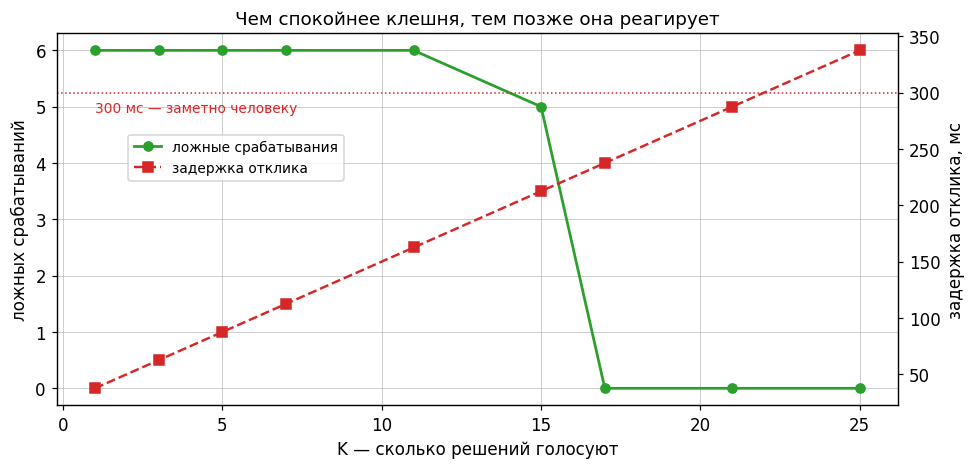

K =  1: ложных 6, задержка 38 мс
K =  3: ложных 6, задержка 62 мс
K =  5: ложных 6, задержка 88 мс
K =  7: ложных 6, задержка 112 мс
K = 11: ложных 6, задержка 162 мс
K = 15: ложных 5, задержка 212 мс
K = 17: ложных 0, задержка 238 мс
K = 21: ложных 0, задержка 288 мс
K = 25: ложных 0, задержка 338 мс


In [7]:
GRID = [1, 3, 5, 7, 11, 15, 17, 21, 25]

triggers, delays = [], []
for k in GRID:
    _, _, sequence = live_loop(signal, k=k)
    triggers.append(false_triggers(sequence, truth))
    delays.append(response_delay(sequence, truth))

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(GRID, triggers, "o-", color="tab:green", lw=1.8, label="ложные срабатывания")
ax.set(xlabel="K — сколько решений голосуют", ylabel="ложных срабатываний")

right = ax.twinx()
right.plot(GRID, delays, "s--", color="tab:red", lw=1.6, label="задержка отклика")
right.axhline(300.0, color="tab:red", ls=":", lw=1.0)
right.text(GRID[0], 292, "300 мс — заметно человеку", color="tab:red", fontsize=9,
           ha="left", va="top")
right.set_ylabel("задержка отклика, мс")
right.grid(False)

ax.set_title("Чем спокойнее клешня, тем позже она реагирует")
fig.legend(loc="upper left", bbox_to_anchor=(0.13, 0.72), fontsize=9)
fig.tight_layout()
plt.show()

for k, count, delay in zip(GRID, triggers, delays):
    print("K = %2d: ложных %d, задержка %.0f мс" % (k, count, delay))

Кривая ложных срабатываний не сползает плавно, а держится на месте и потом
обрывается. Причина в том, как устроено голосование: оно гасит событие,
только если то занимает меньше половины окна голосования. А след 60-мс
всплеска в RMS-окне растянут почти на всю длину окна — короткий толчок
сидит в буфере, пока буфер его не вытолкнет. Поэтому давить нужно не
длительностью всплеска, а длительностью его следа, и `K` требуется заметно
больше, чем кажется.

Задержка при этом уже подбирается к ориентиру в 300 мс. Больше человек
ощущает как «протез тормозит» и начинает подстраиваться под него сам, вместо
того чтобы просто им пользоваться.

Отсюда главный вывод всей серии: **чистить сигнал дешевле, чем давить
последствия**. Один плохо приклеенный электрод (E13) стоит здесь двух сотен
миллисекунд задержки — и никакая логика в контроллере эту цену не отменит.

**Честно про источник.** Всплески мы добавили сами и знаем, где они. На живом
сигнале их никто не размечает, и «ложное срабатывание» приходится определять
по видеозаписи руки или по кнопке в руках испытуемого. Сама же логика цикла —
буфер, RMS, гистерезис, голосование — переносится на железо без единого
изменения.

## Задания

1. Подбери `K`, `THRESHOLD` и `HYSTERESIS` так, чтобы ложных срабатываний не
   осталось, а задержка не превышала 300 мс. Приложи три дорожки и обе цифры.
2. Что делает гистерезис в отрыве от голосования? Поставь `K = 1` и прогони
   `HYSTERESIS` = 0, 0.04, 0.08, 0.2. Почему одним гистерезисом всплески в
   покое не убираются?
3. Сократи `WIN_MS` до 100 мс и повтори прогон по сетке `K`. Что происходит с
   обеими величинами и почему короткое окно помогает именно против всплесков?
4. Увеличь `amplitude` всплесков до 1.5 и повтори подбор. В какой момент
   выгоднее вернуться к E13 и починить контакт электрода, чем добавлять
   задержку?